<a href="https://colab.research.google.com/github/ninobronw/BPALM-TOOL-IMPLEMENTATION/blob/main/SuperKart_Notebook_CLEAN_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem Statement**

## Business Context

A sales forecast is a prediction of future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. A company needs to make an accurate sales forecast as it adds value across an organization and helps the different verticals to chalk out their future course of action.

Forecasting helps an organization plan its sales operations by region and provides valuable insights to the supply chain team regarding the procurement of goods and materials. An accurate sales forecast process has many benefits which include improved decision-making about the future and reduction of sales pipeline and forecast risks. Moreover, it helps to reduce the time spent in planning territory coverage and establish benchmarks that can be used to assess trends in the future.

## Objective

SuperKart is a retail chain operating supermarkets and food marts across various tier cities, offering a wide range of products. To optimize its inventory management and make informed decisions around regional sales strategies, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter.

To operationalize these insights at scale, the company has partnered with a data science firm—not just to build a predictive model based on historical sales data, but to develop and deploy a robust forecasting solution that can be integrated into SuperKart’s decision-making systems and used across its network of stores.

## Data Description

The data contains the different attributes of the various products and stores.The detailed data dictionary is given below.

- **Product_Id** - unique identifier of each product, each identifier having two letters at the beginning followed by a number.
- **Product_Weight** - weight of each product
- **Product_Sugar_Content** - sugar content of each product like low sugar, regular and no sugar
- **Product_Allocated_Area** - ratio of the allocated display area of each product to the total display area of all the products in a store
- **Product_Type** - broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others
- **Product_MRP** - maximum retail price of each product
- **Store_Id** - unique identifier of each store
- **Store_Establishment_Year** - year in which the store was established
- **Store_Size** - size of the store depending on sq. feet like high, medium and low
- **Store_Location_City_Type** - type of city in which the store is located like Tier 1, Tier 2 and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than its Tier 2 and Tier 3 counterparts.
- **Store_Type** - type of store depending on the products that are being sold there like Departmental Store, Supermarket Type 1, Supermarket Type 2 and Food Mart
- **Product_Store_Sales_Total** - total revenue generated by the sale of that particular product in that particular store


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Installing and Importing the necessary libraries**

In [2]:
#Installing the libraries with the specified versions
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 joblib==1.4.2 xgboost==2.1.4 requests==2.32.4 huggingface_hub==0.34.0 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.8/301.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.6/223.6 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 558.7/558.7 kB 35.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.34.0 which is incompatible.
transformers 5.13.1 requires huggingface-hub<2.0,>=1.5.0, but you have huggingface-hub 0.34.0 which is incompatible.


**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [3]:
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# For splitting the dataset
from sklearn.model_selection import train_test_split

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

# Libraries to get different metric scores
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

# To create the pipeline
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline,Pipeline

# To tune different models and standardize
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder

# To serialize the model
import joblib

# os related functionalities
import os

# API request
import requests

# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi

# --- Imports complémentaires utilisés plus bas dans le notebook ---
import xgboost as xgb
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import RandomizedSearchCV


# **Loading the dataset**

In [4]:
# Charger le dataset
data = pd.read_csv('/content/SuperKart.csv')

# Aperçu des 5 premières lignes
data.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


# **Data Overview**

In [21]:
# Dimensions du jeu de données
print("Dimensions :", data.shape)

# Informations sur les colonnes
data.info()

# Statistiques descriptives
print(data.describe())

# Vérification des valeurs manquantes
print("\nValeurs manquantes par colonne :")
print(data.isnull().sum())

Dimensions : (8763, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Id                 8763 non-null   object 
 1   Product_Weight             8763 non-null   float64
 2   Product_Sugar_Content      8763 non-null   object 
 3   Product_Allocated_Area     8763 non-null   float64
 4   Product_Type               8763 non-null   object 
 5   Product_MRP                8763 non-null   float64
 6   Store_Id                   8763 non-null   object 
 7   Store_Establishment_Year   8763 non-null   int64  
 8   Store_Size                 8763 non-null   object 
 9   Store_Location_City_Type   8763 non-null   object 
 10  Store_Type                 8763 non-null   object 
 11  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 821.7+ KB
       Product_Weight

# **Exploratory Data Analysis (EDA)**

## Univariate Analysis

count    8763.000000
mean     3464.003640
std      1065.630494
min        33.000000
25%      2761.715000
50%      3452.340000
75%      4145.165000
max      8000.000000
Name: Product_Store_Sales_Total, dtype: float64


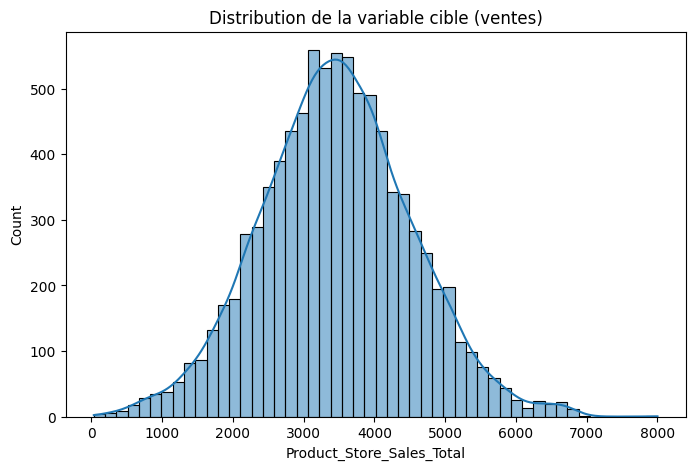

In [22]:
# Variable cible : distribution et statistiques
print(data['Product_Store_Sales_Total'].describe())
plt.figure(figsize=(8, 5))
sns.histplot(data['Product_Store_Sales_Total'], bins=50, kde=True)
plt.title("Distribution de la variable cible (ventes)")
plt.show()

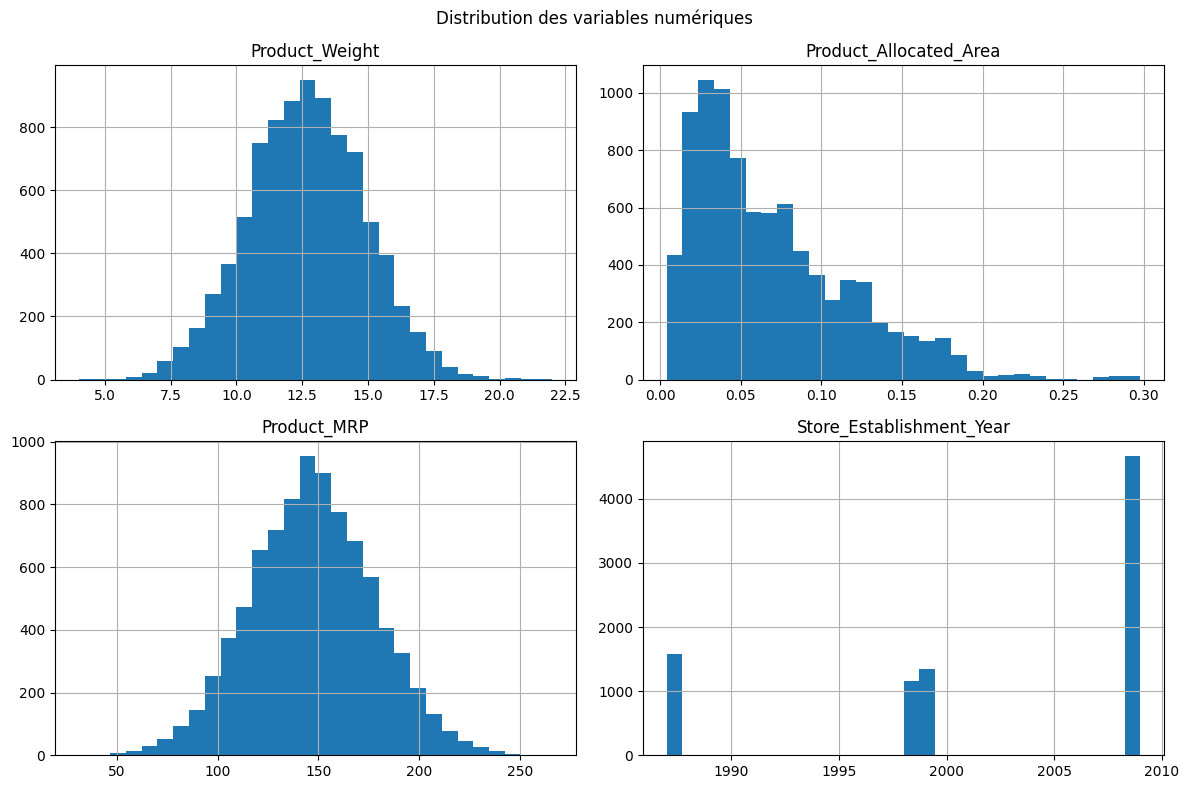

In [7]:
# Variables numériques : un histogramme par variable
numerical_cols = [c for c in data.select_dtypes(include='number').columns
                  if c != 'Product_Store_Sales_Total']
data[numerical_cols].hist(figsize=(12, 8), bins=30)
plt.suptitle("Distribution des variables numériques")
plt.tight_layout()
plt.show()

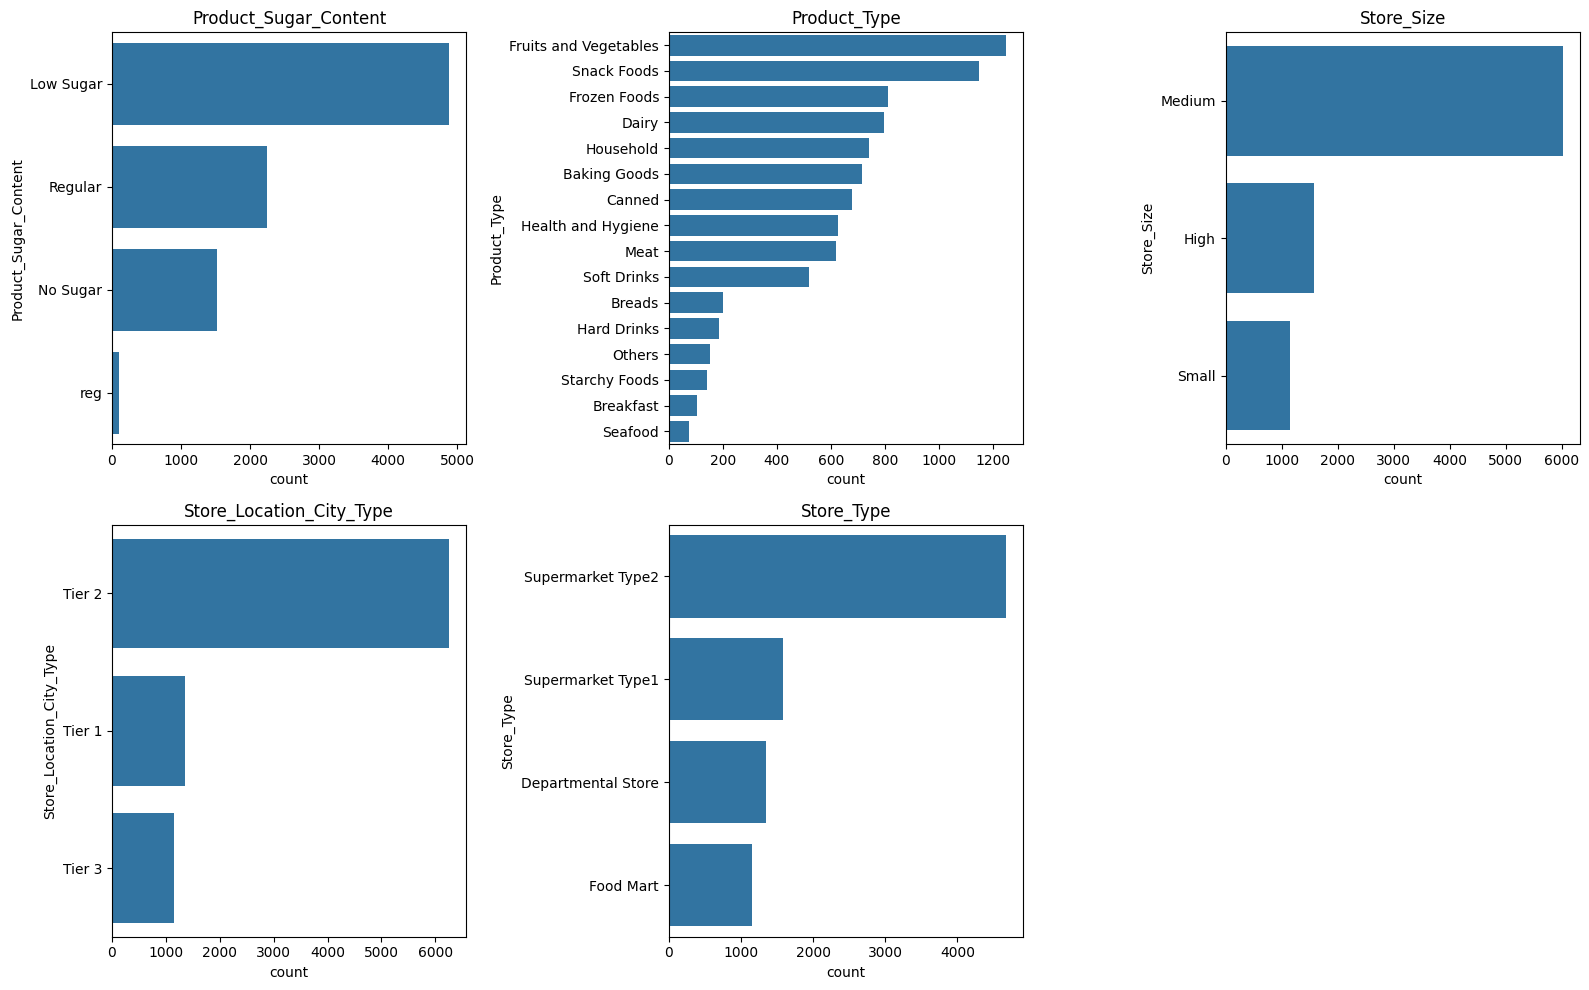

In [8]:
# Variables catégorielles : un countplot par variable (hors identifiants)
categorical_cols = [c for c in data.select_dtypes(include='object').columns
                    if c not in ['Product_Id', 'Store_Id']]
plt.figure(figsize=(16, 10))
for i, col in enumerate(categorical_cols):
    plt.subplot(2, 3, i + 1)
    sns.countplot(y=col, data=data, order=data[col].value_counts().index)
    plt.title(col)
plt.tight_layout()
plt.show()

## Bivariate Analysis

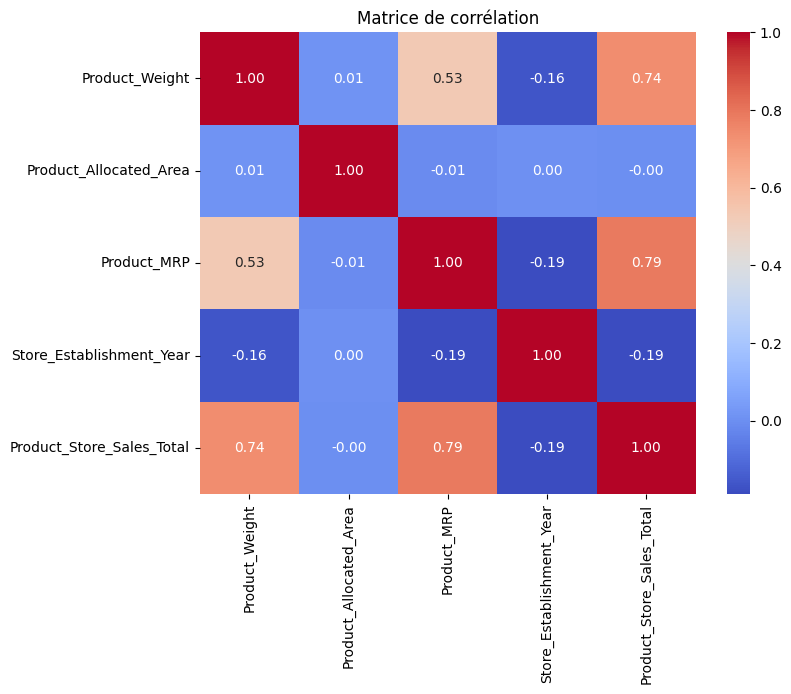

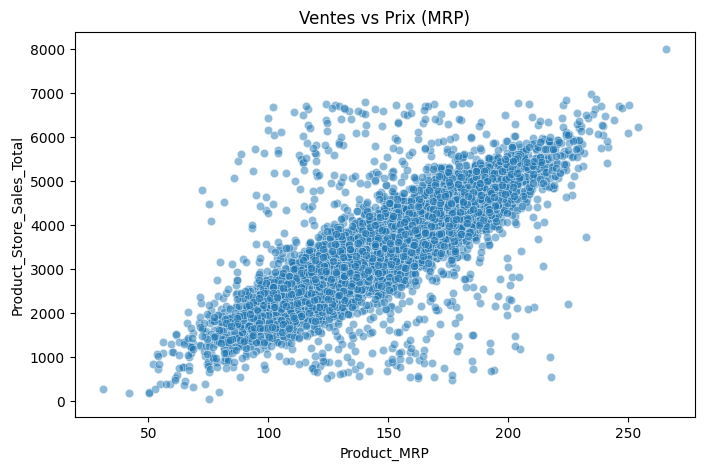

Corrélation ventes / prix : 0.788


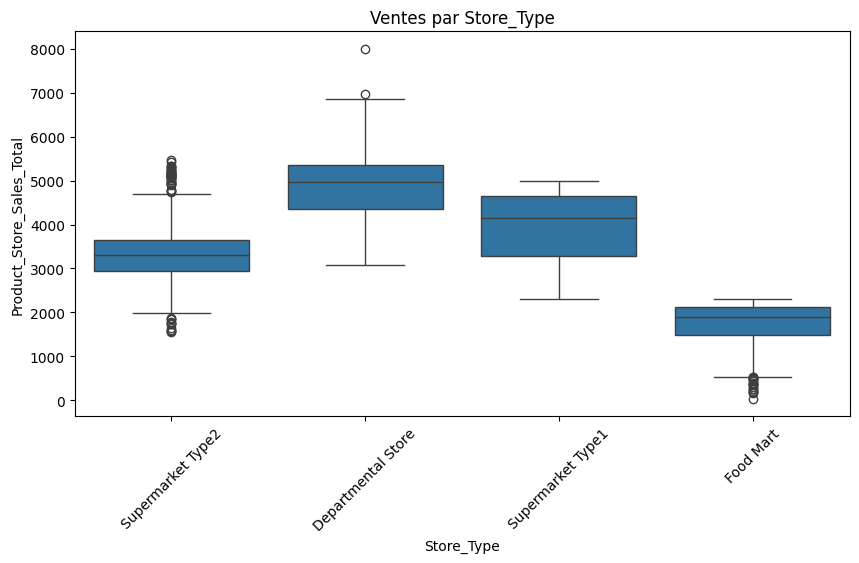

Store_Type
Departmental Store    4946.966323
Supermarket Type1     3923.778802
Supermarket Type2     3299.312111
Food Mart             1762.942465
Name: Product_Store_Sales_Total, dtype: float64


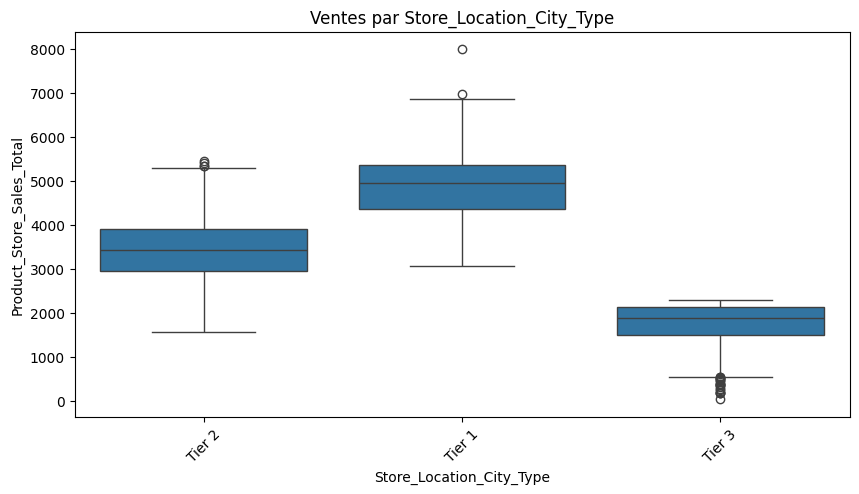

Store_Location_City_Type
Tier 1    4946.966323
Tier 2    3457.473109
Tier 3    1762.942465
Name: Product_Store_Sales_Total, dtype: float64


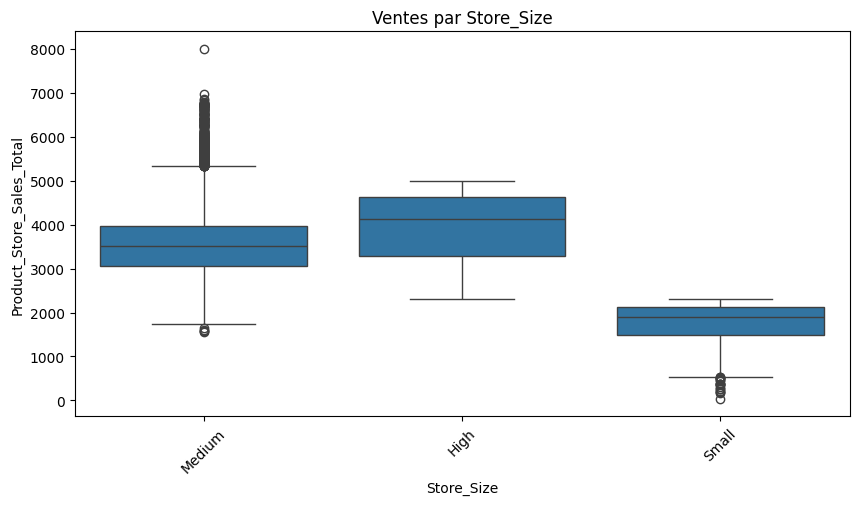

Store_Size
High      3923.778802
Medium    3668.222573
Small     1762.942465
Name: Product_Store_Sales_Total, dtype: float64


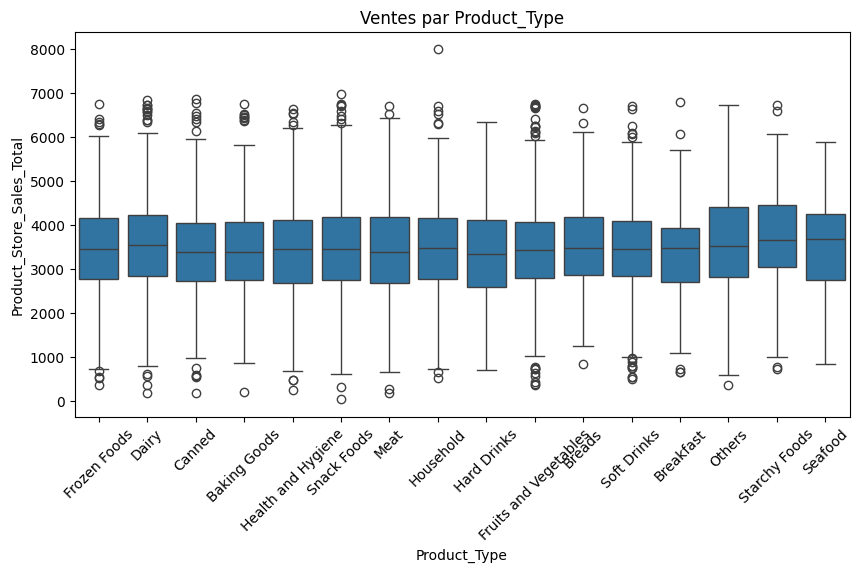

Product_Type
Starchy Foods            3679.251418
Others                   3586.068212
Seafood                  3584.263684
Breads                   3574.711200
Dairy                    3532.560352
Snack Foods              3471.711880
Household                3465.865095
Frozen Foods             3464.834562
Soft Drinks              3462.513911
Health and Hygiene       3445.393646
Meat                     3445.326764
Fruits and Vegetables    3443.421353
Baking Goods             3425.958101
Breakfast                3416.324623
Canned                   3397.463383
Hard Drinks              3364.594731
Name: Product_Store_Sales_Total, dtype: float64


In [9]:
# 1. Corrélations entre variables numériques
plt.figure(figsize=(8, 6))
sns.heatmap(data.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Matrice de corrélation")
plt.show()

# 2. Ventes vs Prix (relation numérique clé)
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Product_MRP', y='Product_Store_Sales_Total', data=data, alpha=0.5)
plt.title("Ventes vs Prix (MRP)")
plt.show()
print("Corrélation ventes / prix :",
      round(data['Product_MRP'].corr(data['Product_Store_Sales_Total']), 3))

# 3. Ventes selon les principales variables catégorielles (chaque relation une seule fois)
for col in ['Store_Type', 'Store_Location_City_Type', 'Store_Size', 'Product_Type']:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=col, y='Product_Store_Sales_Total', data=data)
    plt.title(f"Ventes par {col}")
    plt.xticks(rotation=45)
    plt.show()
    print(data.groupby(col)['Product_Store_Sales_Total'].mean().sort_values(ascending=False))

# **Data Preprocessing**

In [23]:
# --- Traitement des valeurs manquantes ---
# Option 1 : suppression des lignes incomplètes (si peu de données concernées)
data_clean = data.dropna()

# Option 2 : imputation
# Variables numériques -> médiane
num_imputer = SimpleImputer(strategy='median')
data[['Product_Weight', 'Product_MRP']] = num_imputer.fit_transform(data[['Product_Weight', 'Product_MRP']])

# Variables catégorielles -> valeur la plus fréquente
cat_imputer = SimpleImputer(strategy='most_frequent')
data[['Product_Type', 'Store_Type']] = cat_imputer.fit_transform(data[['Product_Type', 'Store_Type']])

# **Model Building**

## Define functions for Model Evaluation

In [24]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mean_absolute_percentage_error(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

In [25]:
# Séparer les colonnes
numeric_cols = ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Establishment_Year']
categorical_cols = ['Product_Sugar_Content', 'Product_Type', 'Store_Size', 'Store_Location_City_Type', 'Store_Type']

# Préparer les transformateurs
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Remplacer les NaN par la médiane
    ('scaler', StandardScaler())  # Standardisation
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Remplacer les NaN par le mode
    ('onehot', OneHotEncoder(drop='first', sparse_output=False))  # One-Hot Encoding
])

# Combiner les transformateurs
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Pipeline complet (prétraitement + modèle)
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(n_estimators=200, learning_rate=0.1, random_state=42))
])

# Séparation train/test
X = data.drop('Product_Store_Sales_Total', axis=1)
y = data['Product_Store_Sales_Total']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entraînement
model_pipeline.fit(X_train, y_train)

# Évaluation
y_pred = model_pipeline.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print(f"MAE sur le jeu de test : {mae:.2f}")

MAE sur le jeu de test : 121.17


In [26]:
df_perf = model_performance_regression(model_pipeline, X_test, y_test)
display(df_perf)

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,288.535209,121.171635,0.927037,0.926576,0.044356


The ML models to be built can be any two out of the following:
1. Decision Tree
2. Bagging
3. Random Forest
4. AdaBoost
5. Gradient Boosting
6. XGBoost

[0]	validation_0-mae:764.29131
[1]	validation_0-mae:695.77975
[2]	validation_0-mae:634.97026
[3]	validation_0-mae:583.91318
[4]	validation_0-mae:532.67797
[5]	validation_0-mae:487.53958
[6]	validation_0-mae:450.86599
[7]	validation_0-mae:418.27520
[8]	validation_0-mae:384.99925
[9]	validation_0-mae:357.78666
[10]	validation_0-mae:334.30161
[11]	validation_0-mae:309.74481
[12]	validation_0-mae:287.33920
[13]	validation_0-mae:267.83546
[14]	validation_0-mae:252.53909
[15]	validation_0-mae:239.80142
[16]	validation_0-mae:226.05406
[17]	validation_0-mae:214.32619
[18]	validation_0-mae:206.44256
[19]	validation_0-mae:200.23269
[20]	validation_0-mae:194.83388
[21]	validation_0-mae:190.67825
[22]	validation_0-mae:185.12353
[23]	validation_0-mae:181.57116
[24]	validation_0-mae:176.55139
[25]	validation_0-mae:170.58514
[26]	validation_0-mae:165.63659
[27]	validation_0-mae:161.31086
[28]	validation_0-mae:156.69228
[29]	validation_0-mae:152.92314
[30]	validation_0-mae:151.19873
[31]	validation_0-

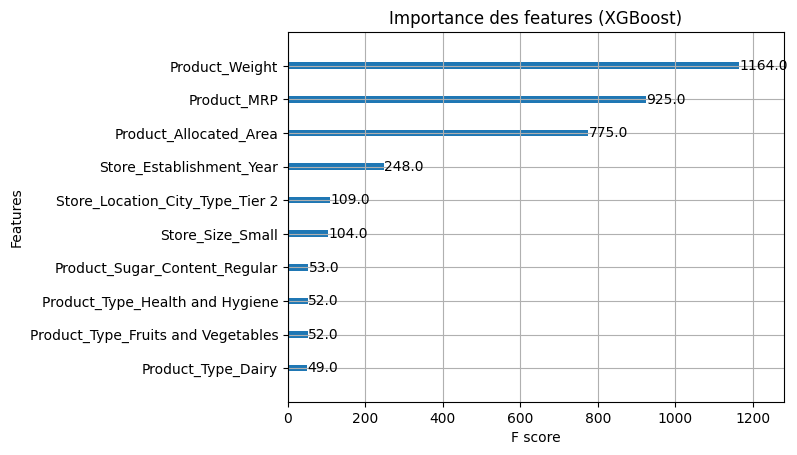

In [27]:
# The X_train, X_test, y_train, y_test variables are already available from previous cells,
# so we don't need to redefine them with train_test_split(X, y, ...) again here.
# They still contain the raw categorical columns.

# Access the preprocessor from the previously defined model_pipeline
preprocessor = model_pipeline.named_steps['preprocessor']

# Transform X_train and X_test using the preprocessor
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Initialiser le modèle XGBoost
model_xgb = xgb.XGBRegressor(
    n_estimators=200,       # Nombre d'arbres (boosting rounds)
    learning_rate=0.1,      # Taux d'apprentissage (plus petit = plus précis mais plus lent)
    max_depth=6,            # Profondeur maximale des arbres (évite le surapprentissage)
    subsample=0.8,          # Utilise 80% des données pour chaque arbre (réduit la variance)
    colsample_bytree=0.8,   # Utilise 80% des features pour chaque arbre (réduit la corrélation)
    random_state=42,
    early_stopping_rounds=10,  # Arrête l'entraînement si le score ne s'améliore pas après 10 rounds
    eval_metric='mae'       # Métrique d'évaluation (MAE pour Mean Absolute Error)
)

# Entraînement avec validation croisée
eval_set = [(X_test_processed, y_test)] # Use processed X_test
model_xgb.fit(
    X_train_processed, y_train, # Use processed X_train
    eval_set=eval_set,
    verbose=True  # Affiche la progression
)

# Prédictions
y_pred_xgb = model_xgb.predict(X_test_processed) # Predict on processed X_test

# Évaluation
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)
print(f"XGBoost - MAE : {mae_xgb:.2f}, R² : {r2_xgb:.2f}")

# Importance des features (pour l'interprétabilité)
# Get feature names after one-hot encoding for plotting
numeric_cols = ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Establishment_Year']
categorical_cols = ['Product_Sugar_Content', 'Product_Type', 'Store_Size', 'Store_Location_City_Type', 'Store_Type']

num_feature_names = numeric_cols
cat_feature_names = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_cols)
all_feature_names = list(num_feature_names) + list(cat_feature_names)

# Assign feature names to the booster model for plotting
model_xgb.get_booster().feature_names = all_feature_names

xgb.plot_importance(model_xgb, max_num_features=10)
plt.title("Importance des features (XGBoost)")
plt.show()

Random Forest - MAE : 114.06, R² : 0.93


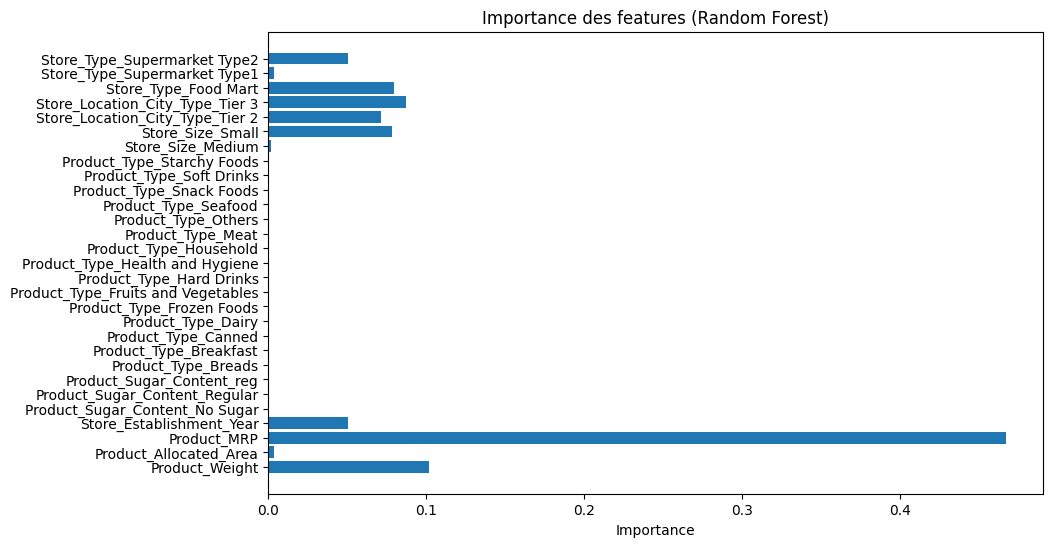

In [28]:
# Initialiser le modèle Random Forest
model_rf = RandomForestRegressor(
    n_estimators=100,       # Nombre d'arbres (plus = meilleur mais plus lent)
    max_depth=10,           # Profondeur maximale des arbres
    min_samples_split=5,    # Nombre minimal d'échantillons pour spliter un nœud
    min_samples_leaf=2,     # Nombre minimal d'échantillons dans une feuille
    random_state=42,
    n_jobs=-1              # Utilise tous les cœurs du CPU
)

# Entraînement avec les données prétraitées
model_rf.fit(X_train_processed, y_train)

# Prédictions sur les données prétraitées
y_pred_rf = model_rf.predict(X_test_processed)

# Évaluation
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print(f"Random Forest - MAE : {mae_rf:.2f}, R² : {r2_rf:.2f}")

# Importance des features
importances = model_rf.feature_importances_
# Utiliser les noms de fonctionnalités générés après le prétraitement
# Ensure all_feature_names is defined (it should be from cSLBTai4QeNA cell)
if 'all_feature_names' not in globals():
    numeric_cols = ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Establishment_Year']
    categorical_cols = ['Product_Sugar_Content', 'Product_Type', 'Store_Size', 'Store_Location_City_Type', 'Store_Type']
    preprocessor = model_pipeline.named_steps['preprocessor']
    num_feature_names = numeric_cols
    cat_feature_names = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_cols)
    all_feature_names = list(num_feature_names) + list(cat_feature_names)

features = all_feature_names

plt.figure(figsize=(10, 6))
plt.barh(features, importances)
plt.title("Importance des features (Random Forest)")
plt.xlabel("Importance")
plt.show()

In [29]:
warnings.filterwarnings("ignore")

# Gradient Boosting (scikit-learn)
model_gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=6)
model_gb.fit(X_train_processed, y_train)

# Prédictions pour Gradient Boosting
y_pred_gb = model_gb.predict(X_test_processed)

# AdaBoost (scikit-learn)
model_ada = AdaBoostRegressor(n_estimators=100, learning_rate=0.1)
model_ada.fit(X_train_processed, y_train)

# Prédictions pour AdaBoost
y_pred_ada = model_ada.predict(X_test_processed)


In [17]:
# Évaluation du modèle Gradient Boosting
df_perf_gb = model_performance_regression(model_gb, X_test_processed, y_test)
print("Performance du Gradient Boosting Regressor:")
display(df_perf_gb)

# Évaluation du modèle AdaBoost
df_perf_ada = model_performance_regression(model_ada, X_test_processed, y_test)
print("\nPerformance de l'AdaBoost Regressor:")
display(df_perf_ada)


Performance du Gradient Boosting Regressor:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,294.8195,121.719528,0.923824,0.922542,0.043771



Performance de l'AdaBoost Regressor:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,474.709026,360.005954,0.802502,0.799178,0.12336


# **Model Performance Improvement - Hyperparameter Tuning**

In [18]:
params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6],
    'min_samples_split': [2, 5, 10]
}

search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    params,
    n_iter=20,
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42
)
# Correction: Utiliser les données prétraitées X_train_processed
search.fit(X_train_processed, y_train)
print("Meilleurs paramètres :", search.best_params_)


Meilleurs paramètres : {'n_estimators': 100, 'min_samples_split': 10, 'max_depth': 6, 'learning_rate': 0.05}


In [19]:
# Entraîner le Gradient Boosting Regressor avec les meilleurs paramètres
model_gb_tuned = GradientBoostingRegressor(**search.best_params_, random_state=42)
model_gb_tuned.fit(X_train_processed, y_train)

# Évaluation du modèle Gradient Boosting optimisé
df_perf_gb_tuned = model_performance_regression(model_gb_tuned, X_test_processed, y_test)
print("Performance du Gradient Boosting Regressor optimisé:")
display(df_perf_gb_tuned)

# Créer un DataFrame pour comparer les performances de tous les modèles
model_performances = pd.DataFrame({
    'Model': ['XGBoost Pipeline', 'XGBoost Standalone', 'Random Forest', 'Gradient Boosting (Untuned)', 'AdaBoost', 'Gradient Boosting (Tuned)'],
    'RMSE': [
        df_perf['RMSE'].iloc[0],
        np.sqrt(mean_squared_error(y_test, y_pred_xgb)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        df_perf_gb['RMSE'].iloc[0],
        df_perf_ada['RMSE'].iloc[0],
        df_perf_gb_tuned['RMSE'].iloc[0]
    ],
    'MAE': [
        df_perf['MAE'].iloc[0],
        mae_xgb,
        mae_rf,
        df_perf_gb['MAE'].iloc[0],
        df_perf_ada['MAE'].iloc[0],
        df_perf_gb_tuned['MAE'].iloc[0]
    ],
    'R-squared': [
        df_perf['R-squared'].iloc[0],
        r2_xgb,
        r2_rf,
        df_perf_gb['R-squared'].iloc[0],
        df_perf_ada['R-squared'].iloc[0],
        df_perf_gb_tuned['R-squared'].iloc[0]
    ],
    'Adj. R-squared': [
        df_perf['Adj. R-squared'].iloc[0],
        adj_r2_score(X_test_processed, y_test, y_pred_xgb),
        adj_r2_score(X_test_processed, y_test, y_pred_rf),
        df_perf_gb['Adj. R-squared'].iloc[0],
        df_perf_ada['Adj. R-squared'].iloc[0],
        df_perf_gb_tuned['Adj. R-squared'].iloc[0]
    ],
    'MAPE': [
        df_perf['MAPE'].iloc[0],
        mean_absolute_percentage_error(y_test, y_pred_xgb),
        mean_absolute_percentage_error(y_test, y_pred_rf),
        df_perf_gb['MAPE'].iloc[0],
        df_perf_ada['MAPE'].iloc[0],
        df_perf_gb_tuned['MAPE'].iloc[0]
    ]
})

print("\nComparaison des performances des modèles:")
display(model_performances.sort_values(by='MAE'))


Performance du Gradient Boosting Regressor optimisé:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,280.502629,116.993708,0.931043,0.929882,0.042776



Comparaison des performances des modèles:


,Model,RMSE,MAE,R-squared,Adj. R-squared,MAPE
2,Random Forest,282.883814,114.059765,0.929867,0.928686,0.040263
5,Gradient Boosting (Tuned),280.502629,116.993708,0.931043,0.929882,0.042776
0,XGBoost Pipeline,288.535209,121.171635,0.927037,0.926576,0.044356
3,Gradient Boosting (Untuned),294.819500,121.719528,0.923824,0.922542,0.043771
1,XGBoost Standalone,290.203848,124.305266,0.926190,0.924948,0.045724
4,AdaBoost,474.709026,360.005954,0.802502,0.799178,0.123360


# **Model Performance Comparison, Final Model Selection, and Serialization**

In [30]:
# S'assurer que le répertoire de sauvegarde existe
if not os.path.exists('backend_files'):
    os.makedirs('backend_files')

# Sélection du meilleur modèle basé sur le MAE le plus bas
best_model_name = model_performances.sort_values(by='MAE').iloc[0]['Model']
print(f"Le meilleur modèle est: {best_model_name}")

# Dans ce cas, le modèle Random Forest est le meilleur, nous allons donc le sauvegarder.
# Si un autre modèle était le meilleur, il faudrait sauvegarder ce modèle.

# Définir le modèle final à sérialiser (ici, model_rf)
final_model = model_rf

# Définir les noms des fichiers pour le modèle sérialisé et le préprocesseur
model_filename = 'backend_files/random_forest_model.joblib'
preprocessor_filename = 'backend_files/preprocessor.joblib'

# Sérialiser (sauvegarder) le modèle et le préprocesseur
joblib.dump(final_model, model_filename)
joblib.dump(preprocessor, preprocessor_filename)
print(f"Le modèle '{best_model_name}' a été sauvegardé sous '{model_filename}'")
print(f"Le préprocesseur a été sauvegardé sous '{preprocessor_filename}'")


Le meilleur modèle est: Random Forest
Le modèle 'Random Forest' a été sauvegardé sous 'backend_files/random_forest_model.joblib'
Le préprocesseur a été sauvegardé sous 'backend_files/preprocessor.joblib'
